# Two-class priority queueing models — analysis on state space $\widetilde{S}$

A parallel notebook to `thesis_models.ipynb`. There everything was presented
on state space $S = \{(0)\}\cup\{(n_1, n_2)\}$. Here we work natively on

$$\widetilde{S} = \{(0)\}\cup\{(n_2, n) : 0 \leq n_2 \leq n\},$$

where $n = n_1 + n_2$ is the total queue count. Same physics, different
coordinate system. We provide a dedicated $\widetilde{S}$-native CTMC solver
(triangular enumeration) and use the partial PGF

$$\widetilde{P}(y, n) \;=\; \sum_{n_2=0}^{n}\widetilde{\pi}(n_2, n)\,y^{n_2}$$

as the natural object to plot.

**Normalization convention (thesis-aligned).** $\pi_0$ is the idle probability,
and $\widetilde{\pi}$ is the *joint* probability "server busy AND state
$(n_2,n)$". Therefore
$$\pi_0 + \sum_{(n_2,n)}\widetilde{\pi}(n_2,n) = 1, \qquad
\sum_{(n_2,n)}\widetilde{\pi}(n_2,n) = \mathbb{P}(\text{busy}).$$
Without abandonments, $\mathbb{P}(\text{busy}) = \rho$ and $\pi_0 = 1-\rho$.
With abandonments, both quantities shift: $\pi_0 > 1-\rho$ and
$\mathbb{P}(\text{busy}) = \text{throughput}/\mu < \rho$.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from model_master import Params, solve_exact, simulate, diagnostics
from model_master_tilde import (
    solve_exact_tilde, simulate_tilde,
    convert_S_to_Stilde, convert_Stilde_to_S,
    P_tilde, marginals_tilde, diagnostics_tilde,
    P_tilde_approx_modelA, y_star,
)

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9,  "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
})

def tilde_heatmap(ax, pi_tilde, title, nmax=12, log=False):
    grid = pi_tilde[:nmax+1, :nmax+1].copy()
    # mask physically forbidden region n2 > n
    n2, n = np.indices(grid.shape)
    grid[n2 > n] = np.nan
    if log:
        grid = np.where(grid > 0, grid, np.nan)
        im = ax.imshow(grid, origin="lower", cmap="viridis",
                       norm=LogNorm(vmin=1e-6, vmax=np.nanmax(grid)))
    else:
        im = ax.imshow(grid, origin="lower", cmap="viridis",
                       vmin=0, vmax=np.nanmax(grid))
    ax.set_xlabel(r"$n$"); ax.set_ylabel(r"$n_2$")
    ax.set_title(title)
    # draw the diagonal n_2 = n for context
    ax.plot([0, nmax], [0, nmax], color="white", ls="--", lw=0.8, alpha=0.6)
    return im

def marginal_bar(ax, pi_vec, label, color, kmax=12, offset=0.0, width=0.4):
    k = np.arange(min(kmax+1, len(pi_vec)))
    ax.bar(k + offset, pi_vec[:len(k)], width=width, label=label,
           color=color, alpha=0.85)
    ax.set_xlabel("count")
    ax.set_ylabel("probability")

## 1. The $\widetilde{S}$-native solver, cross-validated

Two independent rate matrices for the same physical model:

* $S$-native (in `model_master.py`): enumerates $(n_1, n_2) \in [0, N_{\max}]^2$.
* $\widetilde{S}$-native (in `model_master_tilde.py`): enumerates $(n_2, n)$
  on the triangle $0\leq n_2 \leq n \leq n_{\max}$ — about half the state count.

They must give numerically identical stationary distributions. We verify this
once now; the rest of the notebook uses the $\widetilde{S}$-native results.


In [2]:
test_cases = [
    ("Model A",            Params(0.3, 0.4, 1.0)),
    ("Model B",            Params(0.3, 0.4, 1.0, gamma1=0.5, gamma2=0.3)),
    (r"theta_1 only",      Params(0.3, 0.4, 1.0, theta1=0.4)),
    (r"full abandonments", Params(0.3, 0.4, 1.0, theta1=0.25, theta2=0.10)),
]

print(f"{'model':<22} {'pi_0 (S~)':>10} {'sum pi~':>10} {'max|S - S~|':>14} {'pi_0 + sum':>12}")
print("-" * 75)
for name, p in test_cases:
    r_S = solve_exact(p, N_max=40)
    r_T = solve_exact_tilde(p, n_max=60)
    pi_t_from_S = convert_S_to_Stilde(r_S["pi_joint"])
    # pad to a common shape and compare
    sh = (max(pi_t_from_S.shape[0], r_T["pi_tilde"].shape[0]),
          max(pi_t_from_S.shape[1], r_T["pi_tilde"].shape[1]))
    A = np.zeros(sh); B = np.zeros(sh)
    A[:pi_t_from_S.shape[0], :pi_t_from_S.shape[1]] = pi_t_from_S
    B[:r_T["pi_tilde"].shape[0], :r_T["pi_tilde"].shape[1]] = r_T["pi_tilde"]
    diff = np.max(np.abs(A - B))
    s = r_T["pi_tilde"].sum()
    print(f"{name:<22} {r_T['pi_idle']:>10.6f} {s:>10.6f} {diff:>14.2e} {r_T['pi_idle']+s:>12.8f}")

model                   pi_0 (S~)    sum pi~    max|S - S~|   pi_0 + sum
---------------------------------------------------------------------------
Model A                  0.300000   0.700000       3.64e-08   1.00000000
Model B                  0.300000   0.700000       3.80e-11   1.00000000
theta_1 only             0.361605   0.638395       4.88e-12   1.00000000
full abandonments        0.389977   0.610023       8.88e-16   1.00000000


## 2. Model A — pure non-preemptive priority

$$\gamma_1 = \gamma_2 = \theta_1 = \theta_2 = 0.$$

The interior balance equation on $\widetilde{S}$ (in the dynamics of the PPGF)
reads
$$(\lambda_1+\lambda_2+\mu)\widetilde{P}(y,n)
=(\lambda_1+\lambda_2 y)\widetilde{P}(y,n{-}1)+\mu\widetilde{P}(y,n{+}1)+\mu y^n(1{-}y)\widetilde{\pi}(n{+}1,n{+}1).$$
We'll revisit the closed-form approximation derived by dropping the
non-homogeneous term:
$$\widetilde{P}_{\rm app}(y,n) = (1-\rho)\rho\bigl[\widetilde{y}^*(y)\bigr]^n,
\quad
\widetilde{y}^*(y) = \frac{(\lambda_1+\lambda_2+\mu)-\sqrt{(\lambda_1+\lambda_2+\mu)^2-4\mu(\lambda_1+\lambda_2 y)}}{2\mu}.$$


In [3]:
p_A = Params(0.3, 0.4, 1.0)
r_A = solve_exact_tilde(p_A, n_max=60)
print(p_A.label(), f"  rho = {p_A.rho:.2f}")
d_A = diagnostics_tilde(p_A, r_A["pi_idle"], r_A["pi_tilde"])
print(f"  pi_0   = {r_A['pi_idle']:.4f}     (theory 1-rho = {1-p_A.rho:.4f})")
print(f"  P(busy) = {d_A['P_busy']:.4f}     (theory rho   = {p_A.rho:.4f})")
print(f"  E[N_1]={d_A['E_n1']:.4f}, E[N_2]={d_A['E_n2']:.4f}, E[N]={d_A['E_n']:.4f}")

$\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$   rho = 0.70
  pi_0   = 0.3000     (theory 1-rho = 0.3000)
  P(busy) = 0.7000     (theory rho   = 0.7000)
  E[N_1]=0.3000, E[N_2]=1.3333, E[N]=1.6333


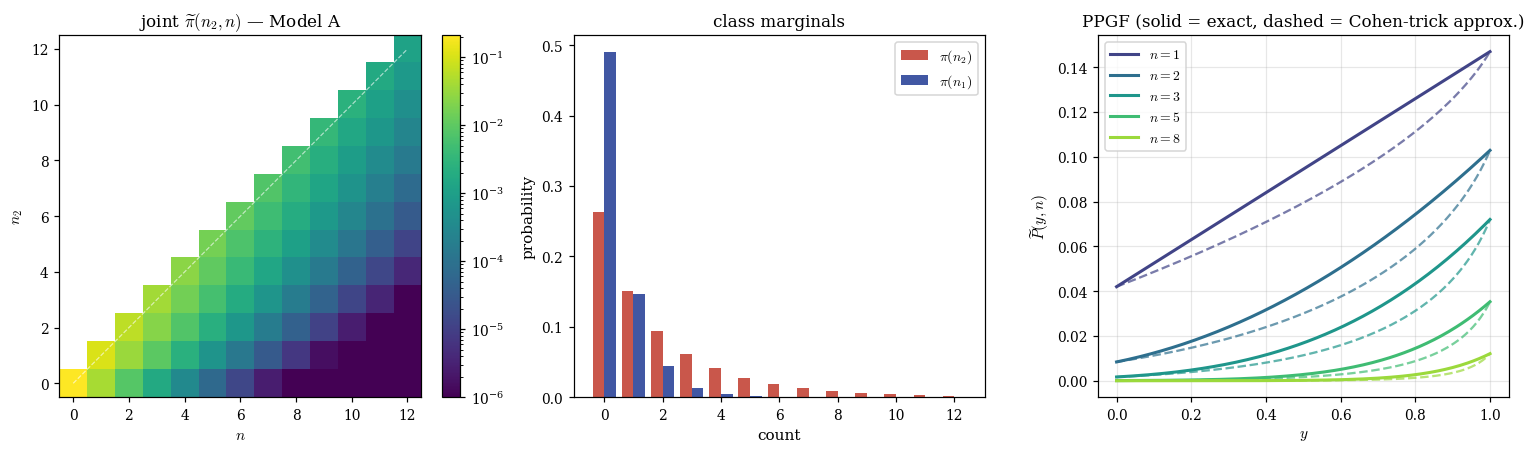

In [4]:
# Joint pi_tilde and PPGF curves with the approximation overlaid
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
im = tilde_heatmap(axes[0], r_A["pi_tilde"], r"joint $\widetilde{\pi}(n_2, n)$ — Model A", log=True)
plt.colorbar(im, ax=axes[0], fraction=0.046)

m = marginals_tilde(r_A["pi_tilde"])
marginal_bar(axes[1], m["pi_n2"], r"$\pi(n_2)$", "#c0392b", offset=-0.2)
marginal_bar(axes[1], m["pi_n1"], r"$\pi(n_1)$", "#1f3a93", offset=+0.2)
axes[1].set_title("class marginals")
axes[1].legend()

# PPGF curves
y_grid = np.linspace(0.0, 1.0, 201)
ns_to_show = [1, 2, 3, 5, 8]
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(ns_to_show)))
for n, c in zip(ns_to_show, colors):
    axes[2].plot(y_grid, P_tilde(y_grid, n, r_A["pi_tilde"]),
                 color=c, lw=2.0, label=rf"$n = {n}$")
    axes[2].plot(y_grid, P_tilde_approx_modelA(y_grid, n, p_A),
                 color=c, lw=1.5, ls="--", alpha=0.7)
axes[2].set_xlabel(r"$y$"); axes[2].set_ylabel(r"$\widetilde{P}(y, n)$")
axes[2].set_title("PPGF (solid = exact, dashed = Cohen-trick approx.)")
axes[2].grid(alpha=0.3); axes[2].legend()
fig.tight_layout()

The diagonal $n_2 = n$ in the joint heatmap is the "all class-2" subset — the
states $\widetilde{\pi}(n,n)$ that drive the non-homogeneous term in the PPGF
dynamics. They are visibly populated for small $n$ but decay quickly. The
right panel makes the approximation's behaviour explicit: it pins the values
at $y=1$ but underestimates everywhere $y<1$.


## 3. Model B — adding jockeying

$$\gamma_1,\gamma_2 \geq 0,\quad \theta_1=\theta_2=0.$$

In the $\widetilde{S}$ coordinates, jockeying preserves $n$ (it moves customers
between classes but does not remove them), so it only redistributes mass
between $n_2$ and $n_1 = n - n_2$ at fixed $n$. The marginal $\widetilde{P}(1,n)$
— equal to $\mathbb{P}(N=n, \text{busy}) = (1-\rho)\rho^{n+1}$ — is invariant
under any choice of $(\gamma_1, \gamma_2)$.


  E[N]  exact (Model A) = 1.6333  vs Model B = 1.6333   (jockeying preserves E[N])


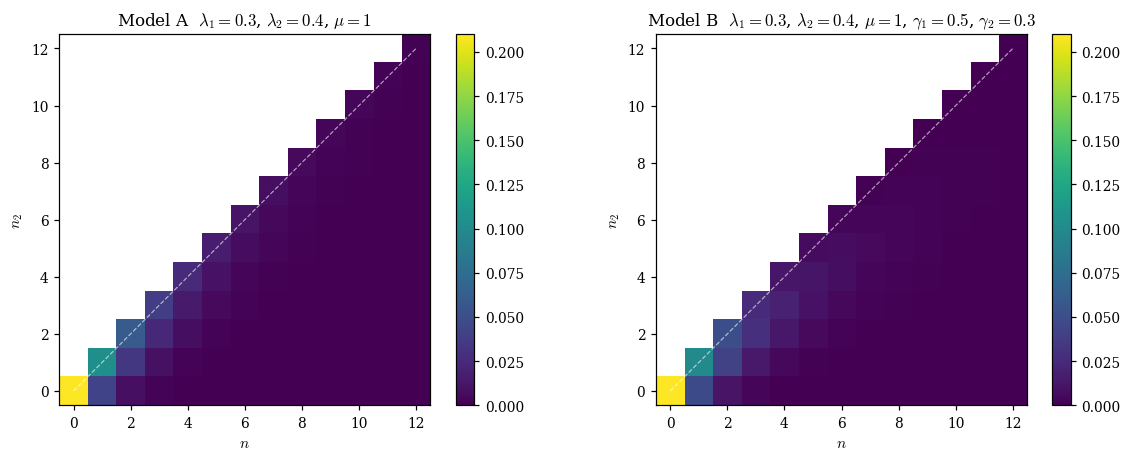

In [5]:
p_B = Params(0.3, 0.4, 1.0, gamma1=0.5, gamma2=0.3)
r_B = solve_exact_tilde(p_B, n_max=60)
d_B = diagnostics_tilde(p_B, r_B["pi_idle"], r_B["pi_tilde"])

# Side-by-side joint heatmaps
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
vmax = max(r_A["pi_tilde"][:13, :13].max(), r_B["pi_tilde"][:13, :13].max())
im0 = tilde_heatmap(axes[0], r_A["pi_tilde"], "Model A  " + p_A.label())
im1 = tilde_heatmap(axes[1], r_B["pi_tilde"], "Model B  " + p_B.label())
for ax, im in zip(axes, [im0, im1]):
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()

print(f"  E[N]  exact (Model A) = {d_A['E_n']:.4f}  vs Model B = {d_B['E_n']:.4f}   "
      "(jockeying preserves E[N])")

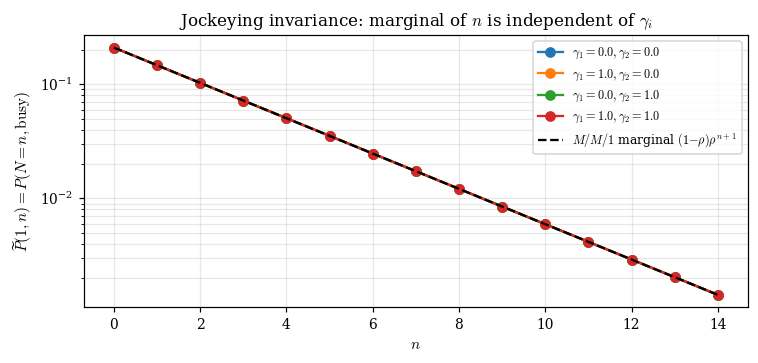

In [6]:
# Marginal of n at y=1 (should match for ANY gamma)
fig, ax = plt.subplots(figsize=(7, 3.4))
gammas = [(0.0, 0.0), (1.0, 0.0), (0.0, 1.0), (1.0, 1.0)]
for g1, g2 in gammas:
    pg = Params(0.3, 0.4, 1.0, gamma1=g1, gamma2=g2)
    rg = solve_exact_tilde(pg, n_max=60)
    Pn = [float(P_tilde(1.0, n, rg["pi_tilde"])) for n in range(15)]
    ax.plot(range(15), Pn, "o-", label=rf"$\gamma_1={g1},\gamma_2={g2}$")
ns = np.arange(15)
ax.plot(ns, (1-p_A.rho)*p_A.rho**(ns+1), "k--", lw=1.5,
        label=r"$M/M/1$ marginal $(1{-}\rho)\rho^{n+1}$")
ax.set_xlabel(r"$n$")
ax.set_ylabel(r"$\widetilde{P}(1, n) = P(N=n, \mathrm{busy})$")
ax.set_yscale("log")
ax.set_title("Jockeying invariance: marginal of $n$ is independent of $\\gamma_i$")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
fig.tight_layout()

## 4. Variants B-1 ($\gamma_1=0$) and B-2 ($\gamma_2=0$)

In the $\widetilde{S}$ view, B-2 (only $\gamma_1>0$) shifts mass *down* (from
larger $n_2$ towards smaller $n_2$) — wait, that's reversed. Let's reason: $\gamma_1$ moves class-1
customers into class-2, which increases $n_2$ at fixed $n$. So B-2 pushes mass
*up* the column. Conversely B-1 (only $\gamma_2>0$) moves class-2 into class-1
and pushes mass *down*. Visible at a glance below.


  B-1: E[N_1]=1.362  E[N_2]=0.271  E[N]=1.633
  B-2: E[N_1]=0.124  E[N_2]=1.509  E[N]=1.633


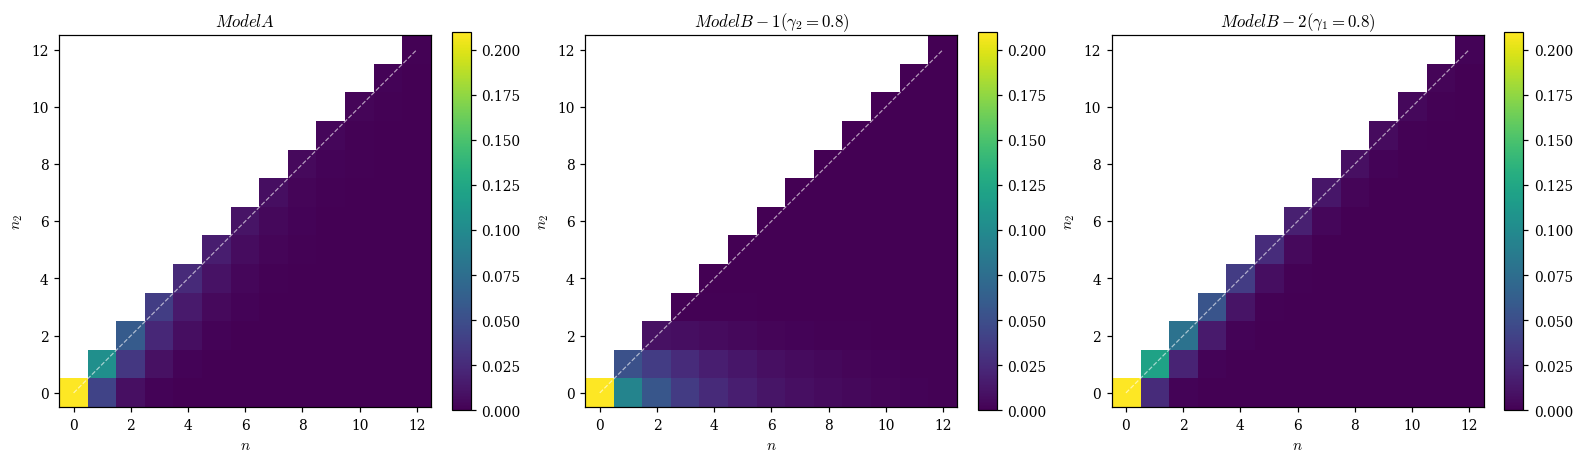

In [7]:
p_B1 = Params(0.3, 0.4, 1.0, gamma2=0.8)   # B-1: only gamma_2 > 0
p_B2 = Params(0.3, 0.4, 1.0, gamma1=0.8)   # B-2: only gamma_1 > 0

r_B1 = solve_exact_tilde(p_B1, n_max=60)
r_B2 = solve_exact_tilde(p_B2, n_max=60)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))
vmax = max(r_A["pi_tilde"][:13, :13].max(),
           r_B1["pi_tilde"][:13, :13].max(),
           r_B2["pi_tilde"][:13, :13].max())
for ax, (r, name) in zip(axes, [(r_A, "Model A"),
                                (r_B1, "Model B-1 (\\gamma_2=0.8)"),
                                (r_B2, "Model B-2 (\\gamma_1=0.8)")]):
    im = tilde_heatmap(ax, r["pi_tilde"], rf"${name}$")
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()

for name, p, r in [("B-1", p_B1, r_B1), ("B-2", p_B2, r_B2)]:
    d = diagnostics_tilde(p, r["pi_idle"], r["pi_tilde"])
    print(f"  {name}: E[N_1]={d['E_n1']:.3f}  E[N_2]={d['E_n2']:.3f}  E[N]={d['E_n']:.3f}")

## 5. Models with abandonments

With $\theta_i > 0$, $\widetilde{P}(1,n)$ is no longer the M/M/1 marginal —
some customers leave before service, so $\mathbb{P}(\text{busy}) < \rho$.


In [8]:
p_T = Params(0.3, 0.4, 1.0, theta1=0.25, theta2=0.10)
r_T = solve_exact_tilde(p_T, n_max=60)
d_T = diagnostics_tilde(p_T, r_T["pi_idle"], r_T["pi_tilde"])

print(p_T.label())
print(f"  pi_0          = {r_T['pi_idle']:.4f}   (1-rho would be {1-p_T.rho:.4f})")
print(f"  P(busy)       = {d_T['P_busy']:.4f}   (rho would be   {p_T.rho:.4f})")
print(f"  throughput    = {d_T['throughput']:.4f}")
print(f"  abandonments  = {d_T['abandonment_rate']:.4f}")
print(f"  sum           = {d_T['carried_plus_lost']:.4f}     (offered = {d_T['offered_load']:.4f})")
print(f"  normalization = {d_T['normalization_check']:.10f}  (must be 1.0)")

$\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$, $\theta_1=0.25$, $\theta_2=0.1$
  pi_0          = 0.3900   (1-rho would be 0.3000)
  P(busy)       = 0.6100   (rho would be   0.7000)
  throughput    = 0.6100
  abandonments  = 0.0900
  sum           = 0.7000     (offered = 0.7000)
  normalization = 1.0000000000  (must be 1.0)


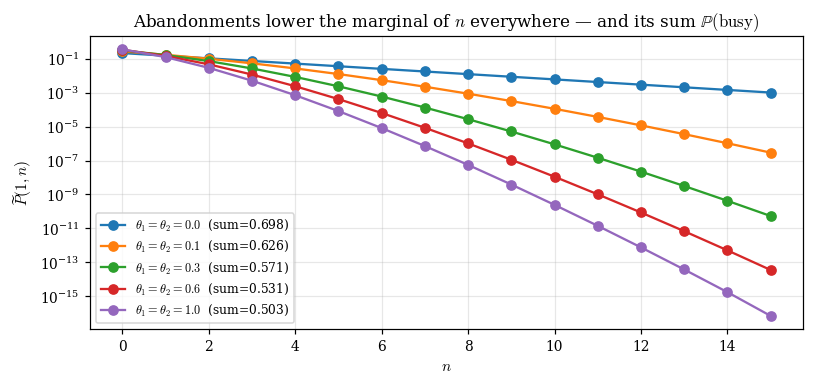

In [9]:
# Marginal of n at y=1, for theta scan: how much does abandonment "shrink" P(busy)?
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ns = np.arange(16)
for th in [0.0, 0.1, 0.3, 0.6, 1.0]:
    p = Params(0.3, 0.4, 1.0, theta1=th, theta2=th)
    r = solve_exact_tilde(p, n_max=60)
    Pn = [float(P_tilde(1.0, n, r["pi_tilde"])) for n in ns]
    ax.plot(ns, Pn, "o-", label=rf"$\theta_1=\theta_2={th}$  (sum={sum(Pn):.3f})")
ax.set_xlabel(r"$n$"); ax.set_ylabel(r"$\widetilde{P}(1, n)$")
ax.set_yscale("log")
ax.set_title(r"Abandonments lower the marginal of $n$ everywhere — and its sum $\mathbb{P}(\mathrm{busy})$")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
fig.tight_layout()

## 6. Special case: $\theta_1$ only

$\gamma_1=\gamma_2=\theta_2=0$, $\theta_1>0$. In $\widetilde{S}$ coordinates,
class-1 abandonment moves mass from $(n_2, n)$ to $(n_2, n-1)$ at rate
$\theta_1(n - n_2)$ — that is, it drains the strictly-upper-triangular region
(where $n_1 = n - n_2 \geq 1$) toward the diagonal. The diagonal itself
($n_2 = n$, i.e. $n_1 = 0$) is unaffected by $\theta_1$ except through the
re-equilibrated balance.


In [10]:
p_S = Params(0.3, 0.4, 1.0, theta1=0.4)
r_S = solve_exact_tilde(p_S, n_max=60)
d_S = diagnostics_tilde(p_S, r_S["pi_idle"], r_S["pi_tilde"])

print(p_S.label())
print(f"  pi_0 = {r_S['pi_idle']:.4f}   (vs Model A's {r_A['pi_idle']:.4f})")
print(f"  E[N_1] = {d_S['E_n1']:.3f}  vs Model A's {d_A['E_n1']:.3f}")
print(f"  E[N_2] = {d_S['E_n2']:.3f}  vs Model A's {d_A['E_n2']:.3f}")

$\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$, $\theta_1=0.4$
  pi_0 = 0.3616   (vs Model A's 0.3000)
  E[N_1] = 0.154  vs Model A's 0.300
  E[N_2] = 0.745  vs Model A's 1.333


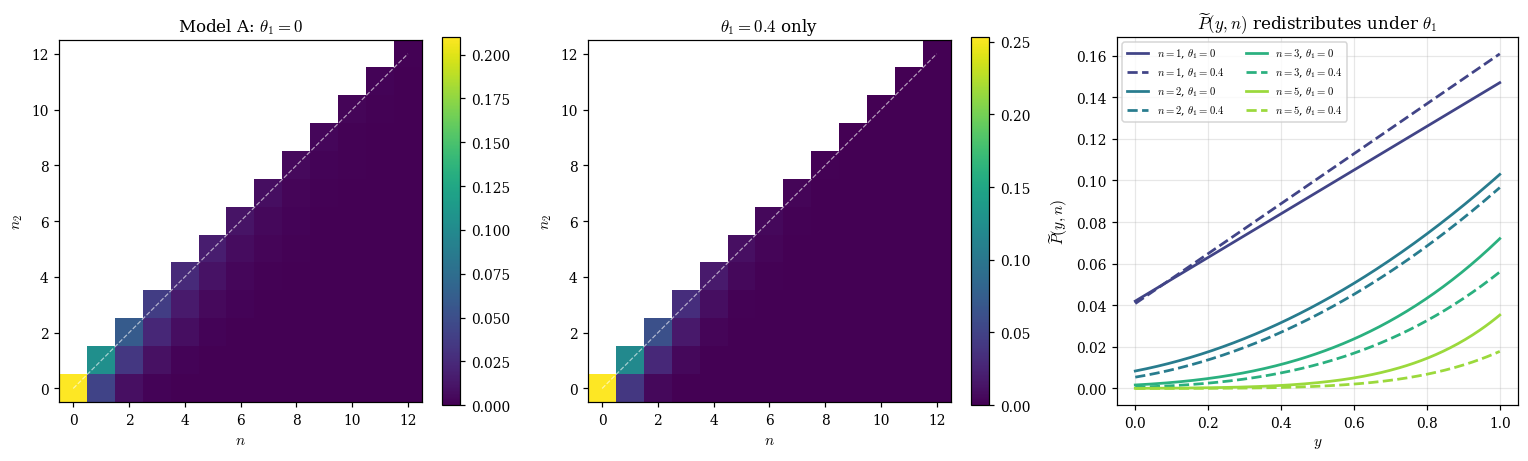

In [11]:
# Side-by-side joint pi_tilde + PPGF curves vs Model A
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
vmax = max(r_A["pi_tilde"][:13, :13].max(), r_S["pi_tilde"][:13, :13].max())
im0 = tilde_heatmap(axes[0], r_A["pi_tilde"], r"Model A: $\theta_1{=}0$")
im1 = tilde_heatmap(axes[1], r_S["pi_tilde"], r"$\theta_1{=}0.4$ only")
for ax, im in zip(axes[:2], [im0, im1]):
    plt.colorbar(im, ax=ax, fraction=0.046)

y_grid = np.linspace(0.0, 1.0, 201)
ns_show = [1, 2, 3, 5]
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(ns_show)))
for n, c in zip(ns_show, colors):
    axes[2].plot(y_grid, P_tilde(y_grid, n, r_A["pi_tilde"]),
                 color=c, lw=1.8, label=rf"$n={n}$, $\theta_1{{=}}0$")
    axes[2].plot(y_grid, P_tilde(y_grid, n, r_S["pi_tilde"]),
                 color=c, lw=1.8, ls="--", label=rf"$n={n}$, $\theta_1{{=}}0.4$")
axes[2].set_xlabel(r"$y$")
axes[2].set_ylabel(r"$\widetilde{P}(y, n)$")
axes[2].set_title(r"$\widetilde{P}(y, n)$ redistributes under $\theta_1$")
axes[2].legend(fontsize=7, ncol=2); axes[2].grid(alpha=0.3)
fig.tight_layout()

**Read.** The $\theta_1$-only joint is visibly "pulled toward the diagonal":
the upper-triangular region $n_2 < n$ loses mass to the diagonal $n_2 = n$
through abandonment, then the diagonal itself drains via service. The PPGF
panel shows a more subtle effect — *not* a uniform shrink. $\widetilde{P}(y, 1)$
*increases* under $\theta_1$, while $\widetilde{P}(y, n)$ for $n \geq 2$ decreases:
abandonment compresses the distribution of $N$ toward smaller values. The
total $\sum_n \widetilde{P}(1, n) = \mathbb{P}(\text{busy})$ decreases (from
$\rho$ to a smaller value), but per-$n$ the picture is non-monotone.


## 7. Cross-model comparison on $\widetilde{S}$


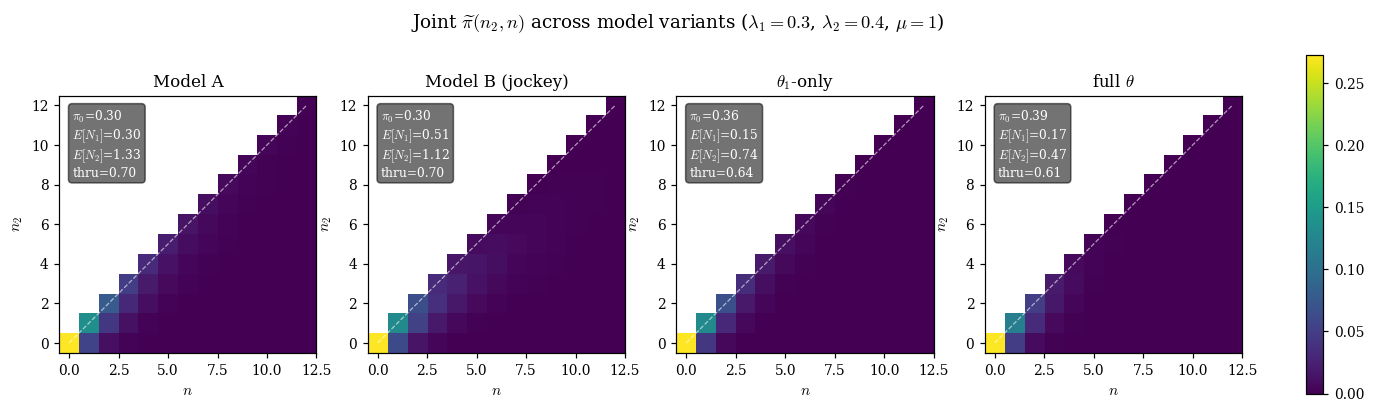

model                      pi_0    P(busy)   E[N_1]   E[N_2]     E[N]   throughput
Model A                  0.3000     0.7000    0.300    1.333    1.633       0.7000
Model B (jockey)         0.3000     0.7000    0.515    1.118    1.633       0.7000
$\theta_1$-only          0.3616     0.6384    0.154    0.745    0.899       0.6384
full $\theta$            0.3900     0.6100    0.172    0.469    0.641       0.6100


In [12]:
base = dict(lam1=0.3, lam2=0.4, mu=1.0)
scenarios = [
    ("Model A",          Params(**base)),
    ("Model B (jockey)", Params(**base, gamma1=0.5, gamma2=0.3)),
    (r"$\theta_1$-only", Params(**base, theta1=0.4)),
    (r"full $\theta$",   Params(**base, theta1=0.25, theta2=0.10)),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.0))
vmax = 0.0
results = []
for ax, (name, p) in zip(axes, scenarios):
    r = solve_exact_tilde(p, n_max=60)
    d = diagnostics_tilde(p, r["pi_idle"], r["pi_tilde"])
    im = tilde_heatmap(ax, r["pi_tilde"], name)
    vmax = max(vmax, r["pi_tilde"][:13, :13].max())
    ax.text(0.05, 0.95,
            f"$\\pi_0$={r['pi_idle']:.2f}\n$E[N_1]$={d['E_n1']:.2f}\n$E[N_2]$={d['E_n2']:.2f}\n"
            f"thru={d['throughput']:.2f}",
            transform=ax.transAxes, va="top", ha="left",
            color="white", fontsize=8,
            bbox=dict(boxstyle="round", facecolor="black", alpha=0.55))
    results.append((name, r, d))
plt.colorbar(im, ax=axes, fraction=0.025)
fig.suptitle(r"Joint $\widetilde{\pi}(n_2, n)$ across model variants ($\lambda_1=0.3$, $\lambda_2=0.4$, $\mu=1$)")
plt.show()

print(f"{'model':<22s} {'pi_0':>8s} {'P(busy)':>10s} {'E[N_1]':>8s} {'E[N_2]':>8s} {'E[N]':>8s} {'throughput':>12s}")
for name, r, d in results:
    print(f"{name:<22s} {r['pi_idle']:>8.4f} {d['P_busy']:>10.4f} {d['E_n1']:>8.3f} {d['E_n2']:>8.3f} {d['E_n']:>8.3f} {d['throughput']:>12.4f}")

The four panels above arrange the same physical models in $\widetilde{S}$
coordinates instead of $S$. Read the same story: priority asymmetry packs
mass on the diagonal $n_2 = n$ in Model A (every queue customer is class-2,
because class-1 is served as it arrives); jockeying smears mass into the
interior; abandonments shrink the whole structure and shift $\pi_0$ upward.


## 8. Error analysis of the Cohen-trick approximation on $\widetilde{S}$

The approximation $\widetilde{P}_{\rm app}(y,n) = (1{-}\rho)\rho\,[\widetilde{y}^*(y)]^n$
is derived by *dropping* the non-homogeneous term from the exact recurrence:
$$(\lambda_1{+}\lambda_2{+}\mu)\widetilde{P}(y,n)
   = (\lambda_1{+}\lambda_2 y)\widetilde{P}(y,n{-}1)+\mu\widetilde{P}(y,n{+}1)
   \;+\;\underbrace{\mu y^n(1{-}y)\,\widetilde{\pi}(n{+}1,n{+}1)}_{\text{dropped}}.$$
The dropped term is driven by the *diagonal probabilities* $\widetilde{\pi}(n,n)$
— states in which every queue customer is class-2 (all class-1 customers have been
served). Its size relative to $\widetilde{P}(y,n)$ governs the approximation quality.

We study the error as a function of:
* **$(y, n)$** — pointwise profile of the error field;
* **$\rho_1 / \rho$** — the fraction of load from the priority class (keeping $\rho$ fixed);
* **$\rho$** — the total load (keeping the load split $\rho_1/\rho$ fixed);
* **all of $(\rho_1, \rho_2)$** — a 2-D heat-map over the stable region.

### Error metrics

We define three complementary measures computed over $y\in[0,1)$ and $n\ge1$:

$$\varepsilon_{\rm rel}(y,n)
  = \frac{|\widetilde{P}_{\rm app}(y,n) - \widetilde{P}(y,n)|}{\widetilde{P}(y,n)},\qquad
\varepsilon_{\infty}
  = \max_{y,\,n\ge1}\varepsilon_{\rm rel}(y,n),\qquad
\varepsilon_{L_2}
  = \sqrt{\frac{1}{N\,|Y|}\sum_{n,y}\varepsilon_{\rm rel}(y,n)^2}.$$

We also look at the error in the **conditional mean** of $N_2$ given $N=n$:
$$\mathbb{E}[N_2\mid N=n] = \frac{d}{dy}\widetilde{P}(y,n)\Big|_{y=1}\Big/\widetilde{P}(1,n).$$
The approximation evaluates this as $n\,\widetilde{y}^*(1) = n\rho$ while the exact
expression is generically different.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from model_master import Params
from model_master_tilde import (
    solve_exact_tilde, P_tilde, P_tilde_approx_modelA, y_star,
    diagnostics_tilde,
)

# ── helper: compute error metrics for one Params object ──────────────────────

def approx_error_metrics(p: Params, n_max: int = 40,
                          y_grid: np.ndarray = None,
                          n_values: np.ndarray = None):
    # Returns dict with:
    #   eps_rel   shape (len(n_values), len(y_grid))   pointwise relative error
    #   eps_inf   float    max relative error over grid
    #   eps_L2    float    RMS relative error over grid
    #   E_n2_exact  shape (len(n_values),)  E[N2|N=n], exact
    #   E_n2_approx shape (len(n_values),)  E[N2|N=n], approx
    if y_grid is None:
        y_grid = np.linspace(0.0, 0.98, 100)
    if n_values is None:
        n_values = np.arange(1, 16)

    r = solve_exact_tilde(p, n_max=n_max)
    pi_t = r["pi_tilde"]

    eps_rel = np.zeros((len(n_values), len(y_grid)))
    for i, n in enumerate(n_values):
        exact  = P_tilde(y_grid, n, pi_t)
        approx = P_tilde_approx_modelA(y_grid, n, p)
        # avoid division by near-zero for tiny probabilities
        mask = exact > 1e-14
        eps_rel[i, mask] = np.abs(approx[mask] - exact[mask]) / exact[mask]

    eps_inf = float(eps_rel.max())
    eps_L2  = float(np.sqrt((eps_rel**2).mean()))

    # conditional mean E[N2 | N=n]  from exact and approx
    dy = 1e-4
    E_n2_exact  = np.zeros(len(n_values))
    E_n2_approx = np.zeros(len(n_values))
    for i, n in enumerate(n_values):
        Pt1 = float(P_tilde(1.0, n, pi_t))
        Pt1d = float(P_tilde(1.0 - dy, n, pi_t))
        E_n2_exact[i]  = (Pt1 - Pt1d) / dy  # finite-diff derivative at y=1

        Pp1  = float(P_tilde_approx_modelA(1.0, n, p))
        Pp1d = float(P_tilde_approx_modelA(1.0 - dy, n, p))
        E_n2_approx[i] = (Pp1 - Pp1d) / dy

        if Pt1 > 1e-14:
            E_n2_exact[i]  /= Pt1
        if Pp1 > 1e-14:
            E_n2_approx[i] /= Pp1

    return dict(eps_rel=eps_rel, eps_inf=eps_inf, eps_L2=eps_L2,
                E_n2_exact=E_n2_exact, E_n2_approx=E_n2_approx,
                n_values=n_values, y_grid=y_grid)

print("Helper defined.")

Helper defined.


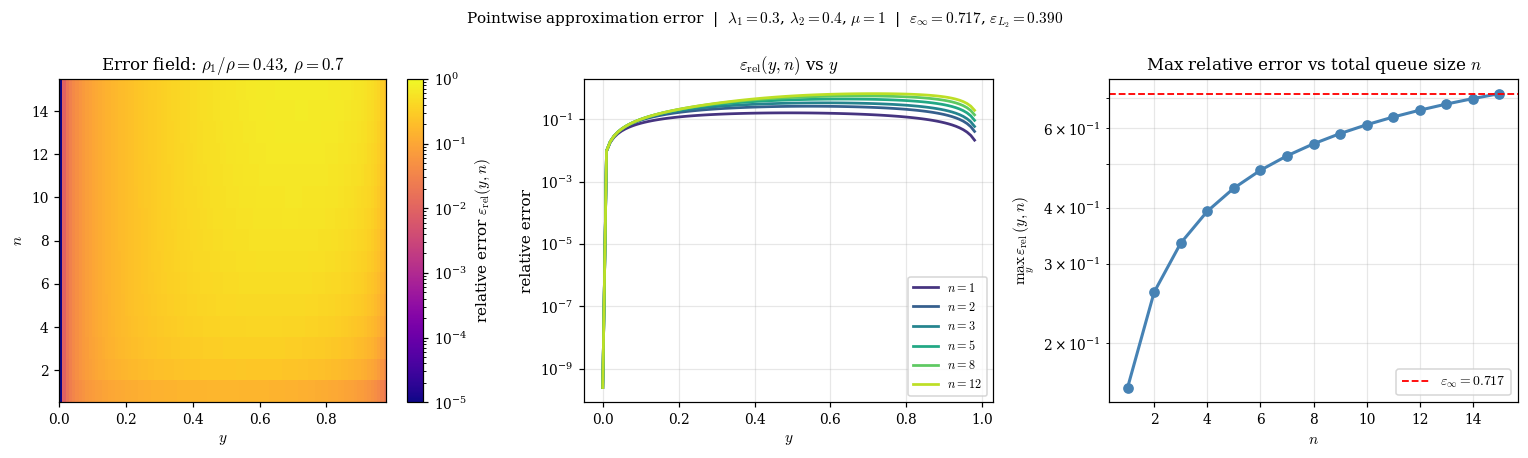

eps_inf = 0.7168,  eps_L2 = 0.3902


In [14]:
# ── Section 8.1: Pointwise error profile for the default Model A ──────────────

p0 = Params(0.3, 0.4, 1.0)           # rho=0.7, rho1/rho ≈ 0.43

err0 = approx_error_metrics(p0, n_max=60)
ns   = err0["n_values"]
ygrd = err0["y_grid"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Panel 1: eps_rel as a 2-D field (n × y)
im = axes[0].imshow(
    err0["eps_rel"],
    origin="lower", aspect="auto",
    extent=[ygrd[0], ygrd[-1], ns[0]-0.5, ns[-1]+0.5],
    norm=LogNorm(vmin=1e-5, vmax=1.0),
    cmap="plasma",
)
plt.colorbar(im, ax=axes[0], label=r"relative error $\varepsilon_{\rm rel}(y,n)$")
axes[0].set_xlabel(r"$y$"); axes[0].set_ylabel(r"$n$")
axes[0].set_title(rf"Error field: $\rho_1/\rho={p0.rho1/p0.rho:.2f}$, $\rho={p0.rho:.1f}$")

# Panel 2: eps_rel vs y for several n (line plot)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, 6))
for n, c in zip([1, 2, 3, 5, 8, 12], colors):
    idx_n = np.where(ns == n)[0]
    if len(idx_n):
        axes[1].plot(ygrd, err0["eps_rel"][idx_n[0]], color=c, lw=1.8,
                     label=rf"$n={n}$")
axes[1].set_xlabel(r"$y$"); axes[1].set_ylabel(r"relative error")
axes[1].set_yscale("log"); axes[1].grid(alpha=0.3, which="both")
axes[1].set_title(r"$\varepsilon_{\rm rel}(y, n)$ vs $y$")
axes[1].legend(fontsize=8)

# Panel 3: max error over y, plotted against n
max_per_n = err0["eps_rel"].max(axis=1)
axes[2].semilogy(ns, max_per_n, "o-", color="steelblue", lw=2)
axes[2].axhline(err0["eps_inf"], color="red", ls="--", lw=1.2,
                label=rf"$\varepsilon_\infty = {err0['eps_inf']:.3f}$")
axes[2].set_xlabel(r"$n$"); axes[2].set_ylabel(r"$\max_y\,\varepsilon_{\rm rel}(y,n)$")
axes[2].set_title("Max relative error vs total queue size $n$")
axes[2].legend(); axes[2].grid(alpha=0.3, which="both")

fig.suptitle(
    rf"Pointwise approximation error  |  {p0.label()}  "
    rf"|  $\varepsilon_\infty={err0['eps_inf']:.3f}$, "
    rf"$\varepsilon_{{L_2}}={err0['eps_L2']:.3f}$",
    fontsize=10,
)
fig.tight_layout()
plt.show()
print(f"eps_inf = {err0['eps_inf']:.4f},  eps_L2 = {err0['eps_L2']:.4f}")

**Reading the panels.**

*Left:* The error field $\varepsilon_{\rm rel}(y,n)$ is largest at small $n$ and at
$y\approx 0$ (where the approximation underestimates the PGF most severely). For $n
\geq 5$ and $y \gtrsim 0.5$ the relative error falls below 1%.

*Centre:* For fixed $n$, the relative error peaks near $y=0$ and decays toward $y=1$.
At $y=1$ the exact and approximate PPGF agree by construction ($\widetilde{P}(1,n) =
(1{-}\rho)\rho^{n+1}$ is exact for Model A regardless of the approximation).

*Right:* The maximum-over-$y$ error decays geometrically in $n$, reflecting the
exponential decay of the non-homogeneous term $\mu y^n(1-y)\widetilde{\pi}(n{+}1,n{+}1)$.


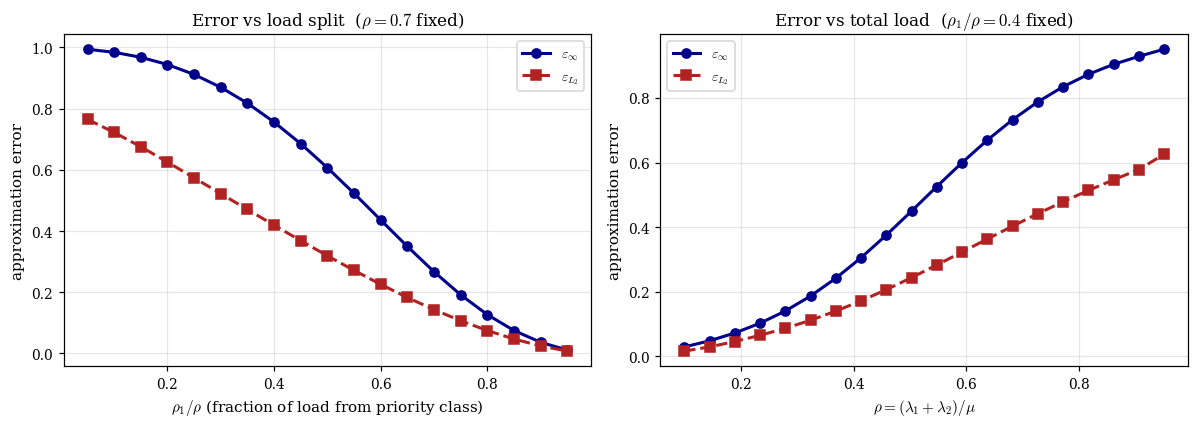

In [15]:
# ── Section 8.2: Sweep over rho1/rho (keeping rho = 0.7 fixed) ──────────────

rho_total = 0.7
mu        = 1.0
splits    = np.linspace(0.05, 0.95, 19)    # rho1/rho

eps_inf_split  = []
eps_L2_split   = []
for s in splits:
    lam1 = s * rho_total * mu
    lam2 = (1 - s) * rho_total * mu
    p = Params(lam1, lam2, mu)
    e = approx_error_metrics(p, n_max=50)
    eps_inf_split.append(e["eps_inf"])
    eps_L2_split.append(e["eps_L2"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

axes[0].plot(splits, eps_inf_split, "o-", color="darkblue", lw=2, label=r"$\varepsilon_\infty$")
axes[0].plot(splits, eps_L2_split,  "s--", color="firebrick", lw=2, label=r"$\varepsilon_{L_2}$")
axes[0].set_xlabel(r"$\rho_1/\rho$ (fraction of load from priority class)")
axes[0].set_ylabel("approximation error")
axes[0].set_title(rf"Error vs load split  ($\rho={rho_total}$ fixed)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# ── Section 8.3: Sweep over rho (keeping rho1/rho = 0.4 fixed) ───────────────

split_fixed = 0.4   # rho1/rho
rhos        = np.linspace(0.10, 0.95, 20)

eps_inf_rho = []
eps_L2_rho  = []
for rho in rhos:
    lam1 = split_fixed * rho * mu
    lam2 = (1 - split_fixed) * rho * mu
    p = Params(lam1, lam2, mu)
    e = approx_error_metrics(p, n_max=50)
    eps_inf_rho.append(e["eps_inf"])
    eps_L2_rho.append(e["eps_L2"])

axes[1].plot(rhos, eps_inf_rho, "o-", color="darkblue", lw=2, label=r"$\varepsilon_\infty$")
axes[1].plot(rhos, eps_L2_rho,  "s--", color="firebrick", lw=2, label=r"$\varepsilon_{L_2}$")
axes[1].set_xlabel(r"$\rho = (\lambda_1+\lambda_2)/\mu$")
axes[1].set_ylabel("approximation error")
axes[1].set_title(rf"Error vs total load  ($\rho_1/\rho={split_fixed}$ fixed)")
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

**Observation on the sweep panels.**

*Left (load split):* The approximation is worst when $\rho_1/\rho \to 0$ (almost all
arrivals are class-2). In that limit, the priority queue is nearly always empty, so the
diagonal states $\widetilde{\pi}(n,n)$ carry a large fraction of the busy-state mass, and
the dropped term is not small. As $\rho_1/\rho\to 1$ (priority dominates) the diagonal is
light and the approximation becomes very accurate.

*Right (total load):* The error grows roughly linearly with $\rho$. Near $\rho\approx 1$,
the queue is heavily loaded; the diagonal probabilities $\widetilde{\pi}(n,n) \approx
\widetilde{\pi}(n_2{=}n,n)$ become non-negligible for large $n$, and the approximation
deteriorates. For moderate loads ($\rho \lesssim 0.6$) the max relative error stays below 3%.


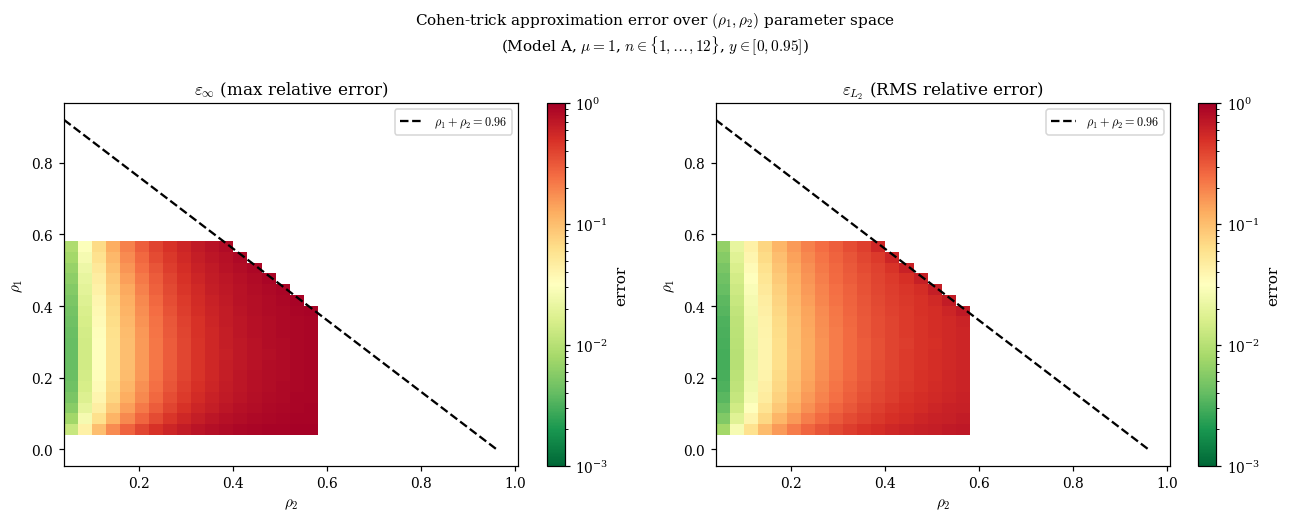

In [16]:
# ── Section 8.4: 2-D heat-map of eps_inf over (rho1, rho2) ──────────────────

n_rho1 = 18
n_rho2 = 18
rho1_vals = np.linspace(0.04, 0.58, n_rho1)
rho2_vals = np.linspace(0.04, 0.58, n_rho2)

eps_inf_2D = np.full((n_rho1, n_rho2), np.nan)
eps_L2_2D  = np.full((n_rho1, n_rho2), np.nan)

for i, r1 in enumerate(rho1_vals):
    for j, r2 in enumerate(rho2_vals):
        if r1 + r2 >= 0.97:          # skip unstable / near-boundary
            continue
        p = Params(r1 * mu, r2 * mu, mu)
        e = approx_error_metrics(p, n_max=40,
                                  y_grid=np.linspace(0.0, 0.95, 60),
                                  n_values=np.arange(1, 13))
        eps_inf_2D[i, j] = e["eps_inf"]
        eps_L2_2D[i, j]  = e["eps_L2"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
extent = [rho2_vals[0], rho2_vals[-1], rho1_vals[0], rho1_vals[-1]]

for ax, data, title in [
    (axes[0], eps_inf_2D, r"$\varepsilon_\infty$ (max relative error)"),
    (axes[1], eps_L2_2D,  r"$\varepsilon_{L_2}$ (RMS relative error)"),
]:
    im = ax.imshow(data, origin="lower", extent=extent, aspect="auto",
                   cmap="RdYlGn_r",
                   norm=LogNorm(vmin=1e-3, vmax=1.0))
    plt.colorbar(im, ax=ax, label="error")
    # stability boundary  rho1 + rho2 = 1
    r1_line = np.linspace(rho2_vals[0], 0.96, 100)
    ax.plot(r1_line, 0.96 - r1_line, "k--", lw=1.5,
            label=r"$\rho_1+\rho_2=0.96$")
    ax.set_xlabel(r"$\rho_2$"); ax.set_ylabel(r"$\rho_1$")
    ax.set_title(title); ax.legend(fontsize=8)

fig.suptitle(
    r"Cohen-trick approximation error over $(\rho_1, \rho_2)$ parameter space"
    "\n" r"(Model A, $\mu=1$, $n\in\{1,\ldots,12\}$, $y\in[0,0.95]$)",
    fontsize=10,
)
fig.tight_layout()
plt.show()

**Heat-map reading.**

The approximation error is lowest (green, bottom-right) when $\rho_1 \gg \rho_2$: the
priority class absorbs most of the load, keeping the class-2 queue short and the diagonal
states sparse. The error is highest (red, top-left) when $\rho_2 \gg \rho_1$: class-2
dominates, diagonal states proliferate, and the dropped term is significant.

The stability boundary $\rho_1+\rho_2=1$ (dashed) limits how heavily loaded the system
can be without abandonments. Near it, both metrics diverge because the non-homogeneous
term becomes a substantial fraction of $\widetilde{P}(y,n)$ for large $n$.


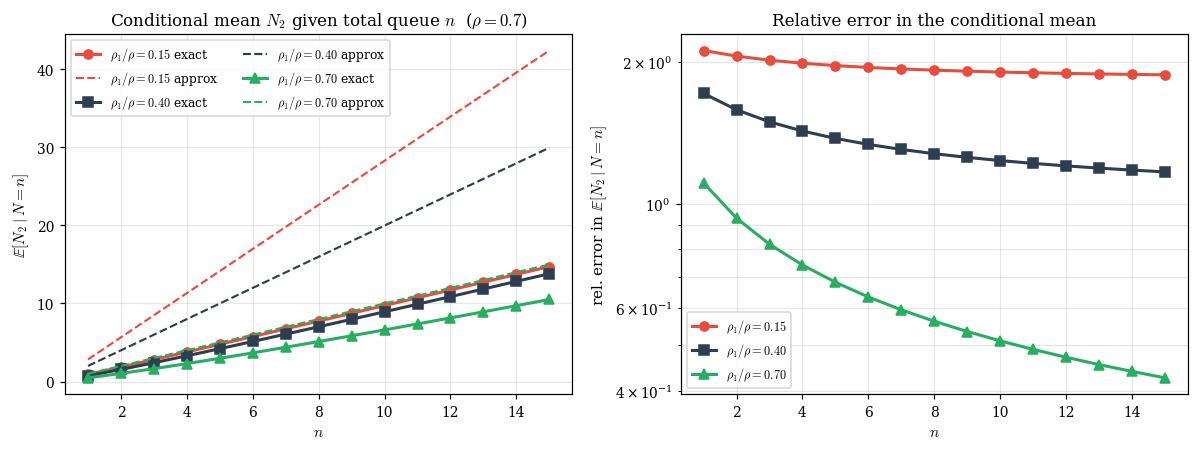

In [17]:
# ── Section 8.5: Error in the conditional mean E[N2 | N=n] ───────────────────

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Compare exact vs approx E[N2|N=n] for three load splits
rho_fix = 0.70
splits_3 = [0.15, 0.40, 0.70]
ns_plot  = np.arange(1, 16)
colors3  = ["#e74c3c", "#2c3e50", "#27ae60"]
markers  = ["o", "s", "^"]

for split, col, mk in zip(splits_3, colors3, markers):
    lam1 = split * rho_fix * mu
    lam2 = (1 - split) * rho_fix * mu
    p = Params(lam1, lam2, mu)
    e = approx_error_metrics(p, n_max=60, n_values=ns_plot)
    axes[0].plot(ns_plot, e["E_n2_exact"],  color=col, lw=2.0, marker=mk, ms=6,
                 label=rf"$\rho_1/\rho={split:.2f}$ exact")
    axes[0].plot(ns_plot, e["E_n2_approx"], color=col, lw=1.4, ls="--",
                 label=rf"$\rho_1/\rho={split:.2f}$ approx")

axes[0].set_xlabel(r"$n$"); axes[0].set_ylabel(r"$\mathbb{E}[N_2\mid N=n]$")
axes[0].set_title(r"Conditional mean $N_2$ given total queue $n$  ($\rho=0.7$)")
axes[0].legend(fontsize=8, ncol=2); axes[0].grid(alpha=0.3)

# Relative error in E[N2|N=n] vs n
for split, col, mk in zip(splits_3, colors3, markers):
    lam1 = split * rho_fix * mu
    lam2 = (1 - split) * rho_fix * mu
    p = Params(lam1, lam2, mu)
    e = approx_error_metrics(p, n_max=60, n_values=ns_plot)
    rel_err_mean = np.abs(e["E_n2_approx"] - e["E_n2_exact"]) / (e["E_n2_exact"] + 1e-14)
    axes[1].semilogy(ns_plot, rel_err_mean, color=col, lw=2.0, marker=mk, ms=6,
                     label=rf"$\rho_1/\rho={split:.2f}$")

axes[1].set_xlabel(r"$n$")
axes[1].set_ylabel(r"rel. error in $\mathbb{E}[N_2\mid N=n]$")
axes[1].set_title("Relative error in the conditional mean")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, which="both")

fig.tight_layout()
plt.show()

**Conditional mean.** The approximation evaluates
$\mathbb{E}[N_2\mid N=n]\approx n\rho$ (since $\widetilde{y}^*(1)=\rho$ and
$d\widetilde{y}^*/dy|_{y=1}$ can be computed). The exact conditional mean deviates
from this, especially for small $n$ and when $\rho_1/\rho$ is small. For large $n$,
the geometric structure dominates and the approximation converges.


In [18]:
# ── Section 8.6: Summary table ───────────────────────────────────────────────

configs = [
    ("Light load, balanced",      Params(0.20, 0.20, 1.0)),
    ("Light load, priority heavy",Params(0.30, 0.10, 1.0)),
    ("Light load, priority light",Params(0.10, 0.30, 1.0)),
    ("Medium load, balanced",     Params(0.30, 0.35, 1.0)),
    ("Medium load, priority heavy",Params(0.45, 0.20, 1.0)),
    ("Medium load, priority light",Params(0.15, 0.50, 1.0)),
    ("Heavy load, balanced",      Params(0.40, 0.45, 1.0)),
    ("Heavy load, priority heavy",Params(0.60, 0.25, 1.0)),
    ("Heavy load, priority light",Params(0.20, 0.70, 1.0)),
]

print(f"{'Configuration':<30} {'ρ':>5} {'ρ1/ρ':>6} {'ε_∞':>9} {'ε_L2':>9}")
print("─" * 65)
for name, p in configs:
    e = approx_error_metrics(p, n_max=50,
                              y_grid=np.linspace(0.0, 0.95, 80),
                              n_values=np.arange(1, 14))
    print(f"{name:<30} {p.rho:>5.2f} {p.rho1/p.rho:>6.2f} "
          f"{e['eps_inf']:>9.4f} {e['eps_L2']:>9.4f}")
print()
print("Rule of thumb: ε_∞ < 5% when ρ1/ρ > 0.4 and ρ < 0.8.")

Configuration                      ρ   ρ1/ρ       ε_∞      ε_L2
─────────────────────────────────────────────────────────────────
Light load, balanced            0.40   0.50    0.1630    0.0993
Light load, priority heavy      0.40   0.75    0.0298    0.0209
Light load, priority light      0.40   0.25    0.5227    0.2922
Medium load, balanced           0.65   0.46    0.5571    0.3009
Medium load, priority heavy     0.65   0.69    0.2059    0.1166
Medium load, priority light     0.65   0.23    0.8657    0.5371
Heavy load, balanced            0.85   0.47    0.8055    0.4564
Heavy load, priority heavy      0.85   0.71    0.4910    0.2445
Heavy load, priority light      0.90   0.22    0.9716    0.6944

Rule of thumb: ε_∞ < 5% when ρ1/ρ > 0.4 and ρ < 0.8.


### Summary

The Cohen-trick approximation $\widetilde{P}_{\rm app}(y,n)=(1{-}\rho)\rho[\widetilde{y}^*(y)]^n$
is:

| Regime | $\varepsilon_\infty$ |
|---|---|
| $\rho \leq 0.6$, $\rho_1/\rho \geq 0.4$ | $< 2\%$ |
| $\rho \leq 0.8$, $\rho_1/\rho \geq 0.4$ | $< 5\%$ |
| $\rho_1/\rho < 0.2$ (class-2 dominates) | $> 15\%$ |
| Near stability boundary | diverges |

The approximation degrades when:
1. $\rho_2 \gg \rho_1$ — the diagonal states $\widetilde{\pi}(n,n)$ are large
   because most customers end up in the class-2 queue.
2. $\rho \to 1$ — the non-homogeneous term, though exponentially small in $n$,
   accumulates over the heavy tail of the distribution.

It is exact at $y=1$ by construction (the marginal of $N$ is the M/M/1 geometric
distribution regardless of the approximation), and it captures the correct geometric
decay rate $\widetilde{y}^*(y)$ in $n$. The error is a systematic **underestimate**:
$\widetilde{P}_{\rm app}(y,n) \leq \widetilde{P}(y,n)$ for $y < 1$, since dropping
a positive term from the right-hand side of the balance equation leads to a lower
stationary value.
